In [1]:
import numpy as numpy
import pandas as pd
from sklearn.model_selection import train_test_split # Para dividir os dados
from sklearn.linear_model import LinearRegression    # O nosso modelo preditivo
from sklearn.metrics import mean_absolute_error, r2_score # Para avaliar o erro do modelo
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataL = pd.read_csv('imobLimpo.csv')

In [3]:
dataL.head()

,Area,Quartos,Ano_Construcao,Preco,Furnishing_Numerico,tipo_localidade,locais,tipos,Piscina
0,2473.192784,4.0,1992,568486.0,2,0,0.0,0,0
1,2353.472711,4.0,2006,577214.0,0,1,1.0,0,1
2,2212.222005,3.0,2012,581300.0,1,2,0.0,1,0
3,2823.886596,6.0,1993,794614.0,0,3,2.0,2,1
4,1869.648721,5.0,2012,493086.0,1,1,0.0,0,0


# modelo de regressao linear

In [4]:

# Divisao do dataset para regressao

X = dataL[['Area']]
y = dataL['Preco']

#dividindo treino de previsao

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de imóveis para Treino: {len(X_train)}")
print(f"Total de imóveis para Teste: {len(X_test)}")


Total de imóveis para Treino: 821
Total de imóveis para Teste: 206


In [5]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

print(f"Por cada metro quadrado a mais, o modelo acha que o preço sobe: R$ {modelo_lr.coef_[0]:.2f}")

Por cada metro quadrado a mais, o modelo acha que o preço sobe: R$ 167.93


In [6]:
# testando modelo de previsao

y_pred = modelo_lr.predict(X_test)

#Avaliação

mae= mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"💰 Erro Médio Absoluto (MAE): R$ {mae:,.2f}")
print(f"📊 R-quadrado (R²): {r2:.2%}")

💰 Erro Médio Absoluto (MAE): R$ 54,811.36
📊 R-quadrado (R²): 73.95%


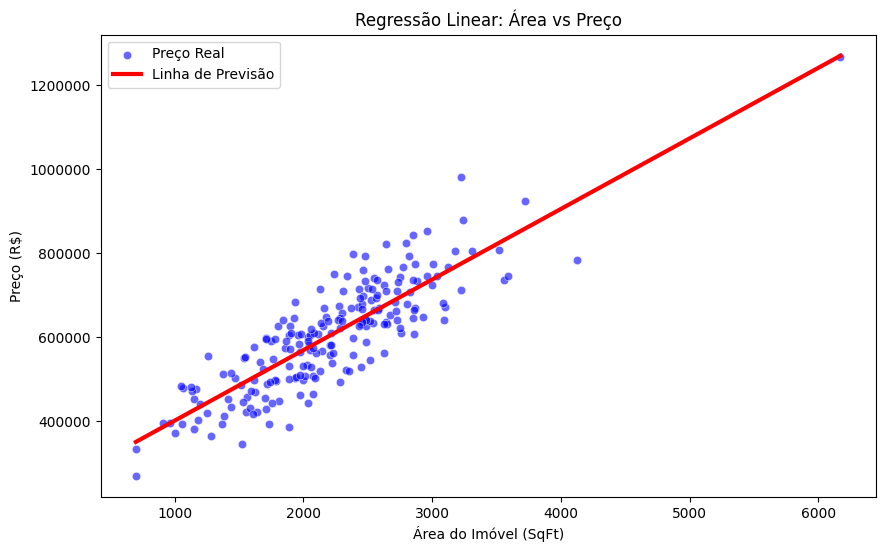

In [7]:
plt.figure(figsize=(10, 6))

# 1. Plotando os pontos reais (usamos os dados de teste para ser justo)
# Os pontos azuis são os preços reais que os imóveis custaram
sns.scatterplot(x=X_test['Area'], y=y_test, color='blue', alpha=0.6, label='Preço Real')

# 2. Plotando a linha de previsão do modelo
# A linha vermelha representa o que o modelo chuta que o preço vai ser baseado na área
sns.lineplot(x=X_test['Area'], y=y_pred, color='red', linewidth=3, label='Linha de Previsão')

plt.title('Regressão Linear: Área vs Preço')
plt.xlabel('Área do Imóvel (SqFt)')
plt.ylabel('Preço (R$)')
plt.ticklabel_format(style='plain', axis='y') # Tira a notação científica do eixo Y
plt.legend()
plt.show()


In [12]:
from numpy import mean
#LMR
dataL = dataL.dropna()
X_multi = dataL.drop('Preco', axis = 1)

y_multi = dataL['Preco']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size= 0.2, random_state = 42)

modelo_lmr = LinearRegression()
modelo_lmr.fit(X_train_m, y_train_m)

y_pred_m = modelo_lmr.predict(X_test_m)

#testes

mae_m = mean_absolute_error(y_test_m, y_pred_m)
r2_m = r2_score(y_test_m, y_pred_m)

print("--- RESULTADOS DA REGRESSÃO MÚLTIPLA ---")
print(f"💰 Novo Erro Médio Absoluto (MAE): R$ {mae_m:,.2f}")
print(f"📊 Novo R-quadrado (R²): {r2_m:.2%}")

--- RESULTADOS DA REGRESSÃO MÚLTIPLA ---
💰 Novo Erro Médio Absoluto (MAE): R$ 38,846.07
📊 Novo R-quadrado (R²): 91.76%


In [13]:
import pandas as pd

# Pegando os nomes das colunas e os "pesos" que o modelo deu pra elas
pesos = pd.DataFrame({
    'Característica': X_train_m.columns, 
    'Impacto no Preço (R$)': modelo_lmr.coef_
})

# Ordenando do maior pro menor
pesos = pesos.sort_values(by='Impacto no Preço (R$)', ascending=False)

print("🔍 O que mais valoriza ou desvaloriza um imóvel?\n")
print(pesos)


🔍 O que mais valoriza ou desvaloriza um imóvel?

        Característica  Impacto no Preço (R$)
7              Piscina           33081.876360
3  Furnishing_Numerico           28006.488324
6                tipos           19324.424371
1              Quartos           18127.159686
4      tipo_localidade           11829.394251
5               locais           11207.231142
2       Ano_Construcao            1293.714178
0                 Area             165.459989


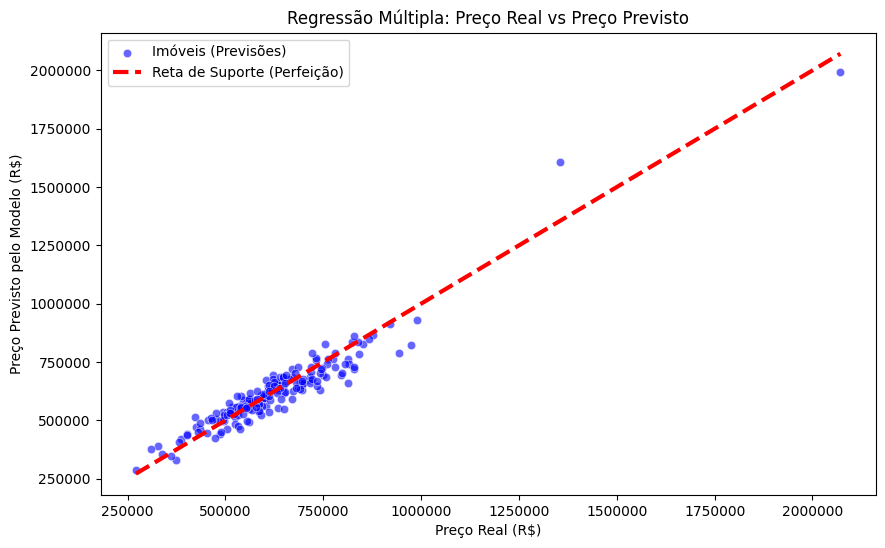

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Plotando as previsões (Preço Real no eixo X e Preço Previsto no eixo Y)
sns.scatterplot(x=y_test_m, y=y_pred_m, color='blue', alpha=0.6, label='Imóveis (Previsões)')

# 2. Desenhando a Reta de Suporte (Linha de Previsão Perfeita: x = y)
# Pegamos o menor e o maior valor para esticar a linha por todo o gráfico
min_val = min(y_test_m.min(), y_pred_m.min())
max_val = max(y_test_m.max(), y_pred_m.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=3, linestyle='--', label='Reta de Suporte (Perfeição)')

# Configurações de exibição
plt.title('Regressão Múltipla: Preço Real vs Preço Previsto')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto pelo Modelo (R$)')
plt.ticklabel_format(style='plain', axis='x') # Tira notação científica do eixo X
plt.ticklabel_format(style='plain', axis='y') # Tira notação científica do eixo Y
plt.legend()
plt.show()



In [15]:
# Random Forest
# Importando o modelo de Floresta Aleatória
from sklearn.ensemble import RandomForestRegressor

# 1. Criando o modelo (Floresta com configuração padrão)
modelo_rf = RandomForestRegressor(random_state=42)

# 2. Treinando o modelo (vamos usar os mesmos dados X_train_m e y_train_m que já tínhamos preparado)
print("Treinando a Floresta Aleatória... isso pode levar alguns segundos!")
modelo_rf.fit(X_train_m, y_train_m)

# 3. Fazendo previsões
y_pred_rf = modelo_rf.predict(X_test_m)

# 4. Avaliando o modelo
mae_rf = mean_absolute_error(y_test_m, y_pred_rf)
r2_rf = r2_score(y_test_m, y_pred_rf)

print("\n--- RESULTADOS DA FLORESTA ALEATÓRIA (RANDOM FOREST) ---")
print(f"💰 Erro Médio Absoluto (MAE): R$ {mae_rf:,.2f}")
print(f"📊 R-quadrado (R²): {r2_rf:.2%}")



Treinando a Floresta Aleatória... isso pode levar alguns segundos!

--- RESULTADOS DA FLORESTA ALEATÓRIA (RANDOM FOREST) ---
💰 Erro Médio Absoluto (MAE): R$ 40,222.49
📊 R-quadrado (R²): 84.18%


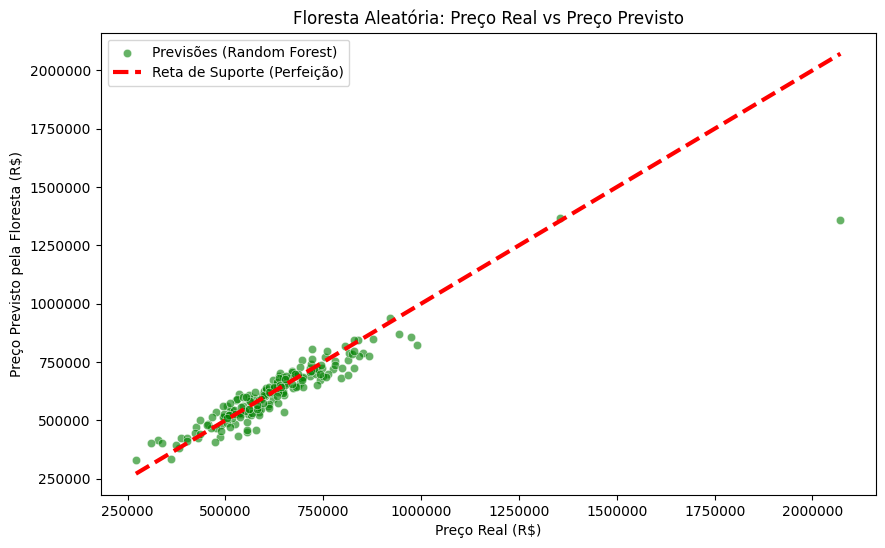

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Plotando as previsões da Floresta Aleatória (usando a cor verde para diferenciar)
sns.scatterplot(x=y_test_m, y=y_pred_rf, color='green', alpha=0.6, label='Previsões (Random Forest)')

# 2. Desenhando a Reta de Suporte (Perfeição)
min_val = min(y_test_m.min(), y_pred_rf.min())
max_val = max(y_test_m.max(), y_pred_rf.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=3, linestyle='--', label='Reta de Suporte (Perfeição)')

# Configurações de exibição
plt.title('Floresta Aleatória: Preço Real vs Preço Previsto')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto pela Floresta (R$)')
plt.ticklabel_format(style='plain', axis='x') # Tira notação científica do eixo X
plt.ticklabel_format(style='plain', axis='y') # Tira notação científica do eixo Y
plt.legend()
plt.show()


In [17]:
# gradient booster

# Importando o modelo Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

# 1. Criando o modelo
modelo_gb = GradientBoostingRegressor(random_state=42)

# 2. Treinando o modelo com os nossos dados
print("Treinando o Gradient Boosting... aguarde um instante!")
modelo_gb.fit(X_train_m, y_train_m)

# 3. Fazendo previsões
y_pred_gb = modelo_gb.predict(X_test_m)

# 4. Avaliando os resultados
mae_gb = mean_absolute_error(y_test_m, y_pred_gb)
r2_gb = r2_score(y_test_m, y_pred_gb)

print("\n--- RESULTADOS DO GRADIENT BOOSTING ---")
print(f"💰 Erro Médio Absoluto (MAE): R$ {mae_gb:,.2f}")
print(f"📊 R-quadrado (R²): {r2_gb:.2%}")



Treinando o Gradient Boosting... aguarde um instante!

--- RESULTADOS DO GRADIENT BOOSTING ---
💰 Erro Médio Absoluto (MAE): R$ 29,607.06
📊 R-quadrado (R²): 88.20%


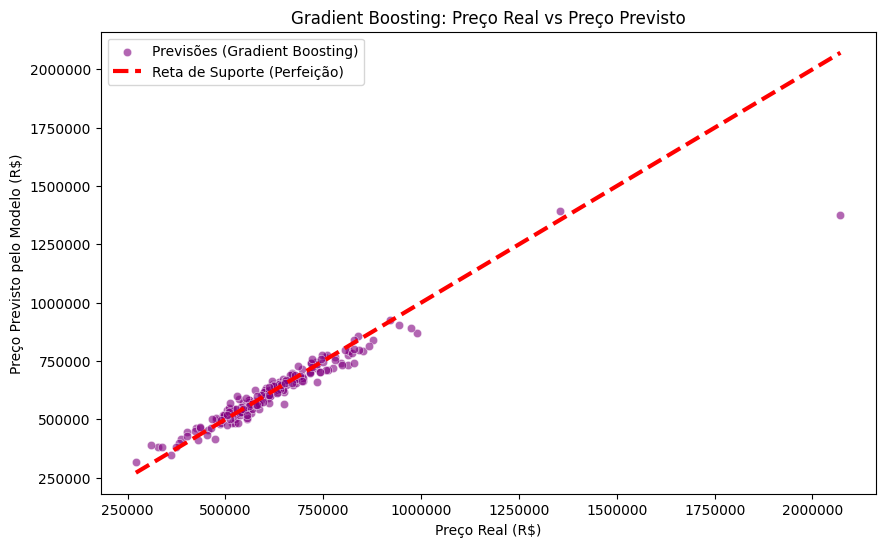

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 1. Plotando as previsões do Gradient Boosting (vamos usar a cor roxa/purple)
sns.scatterplot(x=y_test_m, y=y_pred_gb, color='purple', alpha=0.6, label='Previsões (Gradient Boosting)')

# 2. Desenhando a Reta de Suporte (Perfeição)
min_val = min(y_test_m.min(), y_pred_gb.min())
max_val = max(y_test_m.max(), y_pred_gb.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=3, linestyle='--', label='Reta de Suporte (Perfeição)')

# Configurações de exibição
plt.title('Gradient Boosting: Preço Real vs Preço Previsto')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto pelo Modelo (R$)')
plt.ticklabel_format(style='plain', axis='x') 
plt.ticklabel_format(style='plain', axis='y') 
plt.legend()
plt.show()


In [22]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Colocando os três competidores em um "Dicionário"
modelos = {
    "Regressão Múltipla (RLM)": LinearRegression(),
    "Random Forest (Floresta)": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

print("Iniciando o Raio-X Completo dos Modelos (Aguarde alguns segundos)...\n")

for nome, modelo in modelos.items():
    
    # 1. Validação Cruzada para R²
    notas_r2 = cross_val_score(modelo, X_multi, y_multi, cv=5, scoring='r2')
    r2_medio = notas_r2.mean()
    
    # 2. Validação Cruzada para MAE
    notas_mae = cross_val_score(modelo, X_multi, y_multi, cv=5, scoring='neg_mean_absolute_error')
    mae_medio = -notas_mae.mean()
    
    # 3. Validação Cruzada para RMSE (Punição para outliers)
    notas_rmse = cross_val_score(modelo, X_multi, y_multi, cv=5, scoring='neg_root_mean_squared_error')
    rmse_medio = -notas_rmse.mean()
    
    # 4. Validação Cruzada para MAPE (Erro percentual)
    notas_mape = cross_val_score(modelo, X_multi, y_multi, cv=5, scoring='neg_mean_absolute_percentage_error')
    mape_medio = -notas_mape.mean()
    
    # Exibindo o super relatório formatado
    print(f"🏆 {nome}")
    print(f"   📊 R² Definitivo: {r2_medio:.2%} (O quanto ele entende da precificação)")
    print(f"   💰 MAE Definitivo: R$ {mae_medio:,.2f} (A margem de erro comum do dia a dia)")
    print(f"   🚨 RMSE Definitivo: R$ {rmse_medio:,.2f} (Sensibilidade a erros graves/bizarros)")
    print(f"   📉 MAPE Definitivo: {mape_medio:.2%} (A taxa percentual de erro do valor total)")
    print("-" * 75)
    
print("🏁 COMPETIÇÃO FINALIZADA!")


Iniciando o Raio-X Completo dos Modelos (Aguarde alguns segundos)...

🏆 Regressão Múltipla (RLM)
   📊 R² Definitivo: 88.31% (O quanto ele entende da precificação)
   💰 MAE Definitivo: R$ 35,063.67 (A margem de erro comum do dia a dia)
   🚨 RMSE Definitivo: R$ 48,255.84 (Sensibilidade a erros graves/bizarros)
   📉 MAPE Definitivo: 5.82% (A taxa percentual de erro do valor total)
---------------------------------------------------------------------------
🏆 Random Forest (Floresta)
   📊 R² Definitivo: 89.05% (O quanto ele entende da precificação)
   💰 MAE Definitivo: R$ 34,082.69 (A margem de erro comum do dia a dia)
   🚨 RMSE Definitivo: R$ 48,075.83 (Sensibilidade a erros graves/bizarros)
   📉 MAPE Definitivo: 5.73% (A taxa percentual de erro do valor total)
---------------------------------------------------------------------------
🏆 Gradient Boosting
   📊 R² Definitivo: 93.61% (O quanto ele entende da precificação)
   💰 MAE Definitivo: R$ 24,782.58 (A margem de erro comum do dia a dia

In [25]:
import joblib

# Salvando os três modelos em um dicionário
modelos_exportar = {
    'RLM': modelo_lmr,
    'RF': modelo_rf,
    'GB': modelo_gb
}

# Exportando tudo para um arquivo chamado 'modelos_imobiliarios.pkl'
joblib.dump(modelos_exportar, 'modelos_imobiliarios.pkl')
print("✅ Sucesso! Modelos exportados para o arquivo 'modelos_imobiliarios.pkl'!")


✅ Sucesso! Modelos exportados para o arquivo 'modelos_imobiliarios.pkl'!
